In [1]:
import gc
import json
import math
import sys
import warnings
from pathlib import Path
from dataclasses import dataclass
import matplotlib.pyplot as plt
import matplotlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

warnings.filterwarnings("ignore")

device = torch.device("cuda")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA version: {torch.version.cuda}")

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design
CUDA version: 13.0


### 1. Configuration

In [2]:
@dataclass
class Config:
	train_path: Path = Path("../data/processed/train.parquet")
	val_path: Path = Path("../data/processed/val.parquet")
	test_path: Path = Path("../data/processed/test.parquet")
	raw_path: Path = Path("../data/Global Factor_EM.parquet")
	results_dir: Path = Path("../results")

	d_model: int = 64
	n_heads: int = 4
	n_layers: int = 2
	d_ff: int = 128
	dropout: float = 0.1

	top_k_attention: int = 50
	time2vec_dim: int = 64
	ple_num_bins: int = 16
	periodic_num_freq: int = 32

	n_mlp_layers: int = 2
	lambda_aux: float = 0.3
	min_firms_attention: int = 10

	learning_rate: float = 1e-4
	weight_decay: float = 1e-5
	max_epochs: int = 50
	patience: int = 15
	grad_clip: float = 1.0

	lambda_3m: float = 0.2
	lambda_6m: float = 0.5
	lambda_12m: float = 0.3

	encoding_variant: str = "linear"
	max_firms: int = 5000
	seed: int = 24

cfg = Config()
cfg.results_dir.mkdir(parents = True, exist_ok = True)

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

### 2. Column Classification

In [3]:
with open("../jsons/train_columns.json", "r") as f:
	all_columns = json.load(f)

miss_flags = [c for c in all_columns if c.endswith("_miss")]
miss_bases = [c.replace("_miss", "") for c in miss_flags]
non_miss = [c for c in all_columns if not c.endswith("_miss")]

lag12_cols = [c for c in non_miss if c.endswith("_lag12")]
lag12_bases = [c.replace("_lag12", "") for c in lag12_cols]

K1_CHARS = sorted([c for c in lag12_bases if c in non_miss])
all_chars = sorted([c for c in miss_bases if c in non_miss])
K0_CHARS = sorted([c for c in all_chars if c not in K1_CHARS])

lag_suffixes = ["", "_lag12", "_lag24", "_lag36", "_lag48", "_lag60"]
LAG_POSITIONS = [0, 12, 24, 36, 48, 60]

k0_feature_cols = K0_CHARS.copy()
k1_feature_cols = []
for char in K1_CHARS:
	for suffix in lag_suffixes:
		k1_feature_cols.append(char + suffix)

target_cols = ["target_3m", "target_6m", "target_12m"]

# Split missingness flags into K0 and K1 groups
k0_miss_cols = [f"{c}_miss" for c in K0_CHARS]
k1_miss_cols = [f"{c}_miss" for c in K1_CHARS]

# Build country lookup from raw data
raw_ids = pd.read_parquet(cfg.raw_path, columns = ["id", "eom", "excntry"])
COUNTRY_CODES = sorted(raw_ids["excntry"].unique())
COUNTRY_TO_ID = {c: i for i, c in enumerate(COUNTRY_CODES)}
raw_ids["eom"] = pd.to_datetime(raw_ids["eom"])
raw_ids["country_id"] = raw_ids["excntry"].map(COUNTRY_TO_ID).astype(np.int16)
COUNTRY_LOOKUP = raw_ids[["id", "eom", "country_id"]].drop_duplicates()
del raw_ids
gc.collect()

print(f"K0 characteristics: {len(K0_CHARS)}")
print(f"K1 characteristics: {len(K1_CHARS)} (x6 lags = {len(k1_feature_cols)})")
print(f"K0 miss flags: {len(k0_miss_cols)}")
print(f"K1 miss flags: {len(k1_miss_cols)}")
print(f"Countries: {len(COUNTRY_CODES)}")
for code, idx in COUNTRY_TO_ID.items():
	print(f"  {idx:2d}: {code}")

K0 characteristics: 55
K1 characteristics: 97 (x6 lags = 582)
K0 miss flags: 55
K1 miss flags: 97
Countries: 24
   0: ARE
   1: BRA
   2: CHL
   3: CHN
   4: COL
   5: CZE
   6: EGY
   7: GRC
   8: HUN
   9: IDN
  10: IND
  11: KOR
  12: KWT
  13: MEX
  14: MYS
  15: PER
  16: PHL
  17: POL
  18: QAT
  19: SAU
  20: THA
  21: TUR
  22: TWN
  23: ZAF


### 3. Dataset and Data Loading

In [4]:
class CrossSectionalDataset(Dataset):
	def __init__(self, df, k0_cols, k1_cols, k0_miss, k1_miss, target_cols_list,
				 country_lookup, max_firms):
		self.max_firms = max_firms
		dates = sorted(df["eom"].unique())
		self.monthly_data = []

		n_k1 = len(K1_CHARS)
		df = df.merge(country_lookup, on = ["id", "eom"], how = "left")
		df["country_id"] = df["country_id"].fillna(-1).astype(np.int16)

		for date in dates:
			group = df[df["eom"] == date]
			if len(group) > max_firms:
				group = group.sample(n = max_firms, random_state = 42)

			k0 = torch.tensor(group[k0_cols].values, dtype = torch.float32)
			k1_raw = group[k1_cols].values.astype(np.float32)
			k1 = torch.tensor(k1_raw.reshape(len(group), n_k1, 6), dtype = torch.float32)

			k0_m = torch.tensor(group[k0_miss].values, dtype = torch.float32)
			k1_m = torch.tensor(group[k1_miss].values, dtype = torch.float32)
			cids = torch.tensor(group["country_id"].values, dtype = torch.long)

			targets = {}
			valid_masks = {}
			for tc in target_cols_list:
				vals = group[tc].values.copy().astype(np.float32)
				valid_mask = ~np.isnan(vals)
				vals[~valid_mask] = 0.0
				targets[tc] = torch.tensor(vals, dtype = torch.float32)
				valid_masks[tc] = torch.tensor(valid_mask, dtype = torch.bool)

			self.monthly_data.append({
				"k0": k0, "k1": k1,
				"k0_miss": k0_m, "k1_miss": k1_m,
				"country_ids": cids,
				"targets": targets, "valid_masks": valid_masks,
				"n_firms": len(group),
			})

		del df
		gc.collect()

	def __len__(self):
		return len(self.monthly_data)

	def __getitem__(self, idx):
		return self.monthly_data[idx]


def load_split(path, k0_cols, k1_cols, k0_miss, k1_miss, target_cols_list,
			   country_lookup, max_firms):
	required = ["id", "eom"] + k0_cols + k1_cols + k0_miss + k1_miss + target_cols_list
	df = pd.read_parquet(path, columns = required)

	for col in k0_cols + k1_cols + k0_miss + k1_miss:
		df[col] = df[col].fillna(0.0)

	return CrossSectionalDataset(df, k0_cols, k1_cols, k0_miss, k1_miss,
		target_cols_list, country_lookup, max_firms)

### 4. Architecture Components

#### Time2Vec Temporal Encoding

In [5]:
class Time2Vec(nn.Module):
	def __init__(self, d_out):
		super().__init__()
		self.d_out = d_out
		self.omega = nn.Parameter(torch.randn(d_out))
		self.phi = nn.Parameter(torch.randn(d_out))

	def forward(self, lag_position):
		lag = lag_position.float().unsqueeze(-1)
		raw = self.omega * lag + self.phi
		out = torch.zeros_like(raw)
		out[..., 0] = raw[..., 0]
		out[..., 1:] = torch.sin(raw[..., 1:])
		return out

#### Gated Residual Network

In [6]:
class GRN(nn.Module):
	def __init__(self, d_model, d_ff, dropout = 0.1):
		super().__init__()
		self.fc1 = nn.Linear(d_model, d_ff)
		self.fc2 = nn.Linear(d_ff, d_model * 2)
		self.layer_norm = nn.LayerNorm(d_model)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		residual = x
		h = F.elu(self.fc1(x))
		h = self.dropout(h)
		gated = self.fc2(h)
		value, gate = gated.chunk(2, dim = -1)
		h = value * torch.sigmoid(gate)
		return self.layer_norm(residual + h)

#### Feature Encoding Variants

In [7]:
class LinearEncoder(nn.Module):
	def __init__(self, n_features, d_model):
		super().__init__()
		self.weights = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
		self.biases = nn.Parameter(torch.zeros(n_features, d_model))

	def forward(self, x):
		return x.unsqueeze(-1) * self.weights.unsqueeze(0) + self.biases.unsqueeze(0)


class PerFeatureTokeniser(nn.Module):
	def __init__(self, n_features, d_model):
		super().__init__()
		self.projections = nn.Parameter(torch.randn(n_features, 1, d_model) * 0.02)
		self.biases = nn.Parameter(torch.zeros(n_features, d_model))

	def forward(self, x):
		x_exp = x.unsqueeze(-1)
		proj = self.projections.squeeze(1).unsqueeze(0)
		return x_exp * proj + self.biases.unsqueeze(0)


class PiecewiseLinearEncoder(nn.Module):
	def __init__(self, n_features, d_model, num_bins = 16):
		super().__init__()
		self.num_bins = num_bins
		boundaries = torch.linspace(-0.5, 0.5, num_bins + 1)
		self.register_buffer("boundaries", boundaries)
		self.feature_weights = nn.Parameter(torch.randn(n_features, num_bins, d_model) * 0.02)

	def _encode_bins(self, x):
		t_lower = self.boundaries[:-1]
		t_upper = self.boundaries[1:]
		x_exp = x.unsqueeze(-1)
		activations = torch.clamp((x_exp - t_lower) / (t_upper - t_lower + 1e-8), 0.0, 1.0)
		return activations

	def forward(self, x):
		bin_act = self._encode_bins(x)
		out = torch.einsum("bnk,nkd->bnd", bin_act, self.feature_weights)
		return out


class PeriodicEncoder(nn.Module):
	def __init__(self, n_features, d_model, num_freq = 32):
		super().__init__()
		self.num_freq = num_freq
		self.omega = nn.Parameter(torch.randn(n_features, num_freq) * 0.1)
		self.phi = nn.Parameter(torch.randn(n_features, num_freq) * 0.1)
		self.proj = nn.Linear(num_freq, d_model)

	def forward(self, x):
		x_exp = x.unsqueeze(-1)
		sinusoidal = torch.sin(x_exp * self.omega.unsqueeze(0) + self.phi.unsqueeze(0))
		out = self.proj(sinusoidal)
		return out
	
class FourierEncoder(nn.Module):
	def __init__(self, n_features, d_model, num_freq = 32):
		super().__init__()
		self.num_freq = num_freq
		self.omega = nn.Parameter(torch.randn(n_features, num_freq) * 0.1)
		self.proj = nn.Linear(num_freq * 2, d_model)

	def forward(self, x):
		x_exp = x.unsqueeze(-1)
		scaled = x_exp * self.omega.unsqueeze(0)
		features = torch.cat([torch.sin(scaled), torch.cos(scaled)], dim = -1)
		out = self.proj(features)
		return out


def build_encoder(variant, n_features, d_model, ple_bins = 16, periodic_freq = 32):
	if variant == "linear":
		return LinearEncoder(n_features, d_model)
	elif variant == "per_feature":
		return PerFeatureTokeniser(n_features, d_model)
	elif variant == "ple":
		return PiecewiseLinearEncoder(n_features, d_model, num_bins = ple_bins)
	elif variant == "periodic":
		return PeriodicEncoder(n_features, d_model, num_freq = periodic_freq)
	elif variant == "fourier":
		return FourierEncoder(n_features, d_model, num_freq = periodic_freq)
	else:
		raise ValueError(f"Unknown encoding variant: {variant}")

#### Multi-Head Sparse Attention

In [8]:
class SparseMultiHeadAttention(nn.Module):
	def __init__(self, d_model, n_heads, top_k, dropout = 0.1):
		super().__init__()
		assert d_model % n_heads == 0
		self.d_model = d_model
		self.n_heads = n_heads
		self.d_k = d_model // n_heads
		self.top_k = top_k

		self.W_q = nn.Linear(d_model, d_model)
		self.W_k = nn.Linear(d_model, d_model)
		self.W_v = nn.Linear(d_model, d_model)
		self.W_o = nn.Linear(d_model, d_model)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		n_firms = x.shape[0]
		x = x.unsqueeze(0)

		Q = self.W_q(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)
		K = self.W_k(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)
		V = self.W_v(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)

		scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

		k = min(self.top_k, n_firms)
		topk_vals, _ = scores.topk(k, dim = -1)
		threshold = topk_vals[..., -1:].detach()
		mask = scores < threshold
		scores = scores.masked_fill(mask, float("-inf"))

		attn_weights = F.softmax(scores, dim = -1)
		attn_weights = self.dropout(attn_weights)

		context = torch.matmul(attn_weights, V)
		context = context.transpose(1, 2).contiguous().view(1, n_firms, self.d_model)
		out = self.W_o(context).squeeze(0)

		return out, attn_weights.squeeze(0)

#### Transformer Encoder Block

In [9]:
class TransformerBlock(nn.Module):
	def __init__(self, d_model, n_heads, d_ff, top_k, dropout = 0.1):
		super().__init__()
		self.norm1 = nn.LayerNorm(d_model)
		self.attention = SparseMultiHeadAttention(d_model, n_heads, top_k, dropout)
		self.grn = GRN(d_model, d_ff, dropout)

	def forward(self, x):
		normed = self.norm1(x)
		attn_out, attn_weights = self.attention(normed)
		x = x + attn_out
		x = self.grn(x)
		return x, attn_weights

#### Dual Path Portfolio Transformer

In [10]:
class AttentiveAggregation(nn.Module):
	"""Attention-weighted feature pooling with missingness masking."""
	def __init__(self, d_model):
		super().__init__()
		self.query = nn.Parameter(torch.randn(d_model) * 0.02)
		self.miss_penalty = nn.Parameter(torch.tensor(5.0))
		self.scale = math.sqrt(d_model)

	def forward(self, encoded, miss_mask = None):
		scores = (encoded * self.query).sum(dim = -1) / self.scale
		if miss_mask is not None:
			scores = scores - self.miss_penalty * miss_mask
		weights = F.softmax(scores, dim = 1)
		token = (encoded * weights.unsqueeze(-1)).sum(dim = 1)
		return token, weights


class K1TwoLevelAggregation(nn.Module):
	"""Two-level attention aggregation: first across lags, then across K1 features."""
	def __init__(self, d_model):
		super().__init__()
		self.lag_query = nn.Parameter(torch.randn(d_model) * 0.02)
		self.feat_query = nn.Parameter(torch.randn(d_model) * 0.02)
		self.miss_penalty = nn.Parameter(torch.tensor(5.0))
		self.scale = math.sqrt(d_model)

	def forward(self, k1_encoded, miss_mask = None):
		# k1_encoded: (n_firms, 6, n_k1, d)
		# miss_mask: (n_firms, n_k1)
		lag_scores = (k1_encoded * self.lag_query).sum(dim = -1) / self.scale
		lag_weights = F.softmax(lag_scores, dim = 1)
		h_bar = (k1_encoded * lag_weights.unsqueeze(-1)).sum(dim = 1)

		feat_scores = (h_bar * self.feat_query).sum(dim = -1) / self.scale
		if miss_mask is not None:
			feat_scores = feat_scores - self.miss_penalty * miss_mask
		feat_weights = F.softmax(feat_scores, dim = 1)
		token = (h_bar * feat_weights.unsqueeze(-1)).sum(dim = 1)
		return token, lag_weights, feat_weights


class FirmScoreHead(nn.Module):
	"""Per-firm MLP scoring head with tunable depth."""
	def __init__(self, d_model, d_ff, n_layers, dropout):
		super().__init__()
		modules = [nn.LayerNorm(d_model)]
		for i in range(n_layers):
			in_dim = d_model if i == 0 else d_ff
			modules.extend([nn.Linear(in_dim, d_ff), nn.ELU(), nn.Dropout(dropout)])
		modules.append(nn.Linear(d_ff if n_layers > 0 else d_model, 1))
		self.net = nn.Sequential(*modules)

	def forward(self, z):
		return self.net(z).squeeze(-1)


class DualPathTransformer(nn.Module):
	def __init__(self, config):
		super().__init__()
		self.config = config
		n_k0 = len(K0_CHARS)
		n_k1 = len(K1_CHARS)

		# Feature encoders (shared across both paths)
		self.k0_encoder = build_encoder(
			config.encoding_variant, n_k0, config.d_model,
			ple_bins = config.ple_num_bins, periodic_freq = config.periodic_num_freq
		)
		self.k1_encoder = build_encoder(
			config.encoding_variant, n_k1, config.d_model,
			ple_bins = config.ple_num_bins, periodic_freq = config.periodic_num_freq
		)

		self.time2vec = Time2Vec(config.d_model)
		self.k0_static_emb = nn.Parameter(torch.randn(n_k0, config.d_model) * 0.02)

		# Attention-weighted aggregation with missingness masking
		self.k0_agg = AttentiveAggregation(config.d_model)
		self.k1_agg = K1TwoLevelAggregation(config.d_model)

		# Path 1: per-firm base score heads
		self.base_head_3m = FirmScoreHead(config.d_model, config.d_ff, config.n_mlp_layers, config.dropout)
		self.base_head_6m = FirmScoreHead(config.d_model, config.d_ff, config.n_mlp_layers, config.dropout)
		self.base_head_12m = FirmScoreHead(config.d_model, config.d_ff, config.n_mlp_layers, config.dropout)

		# Path 2: cross-sectional attention blocks (shared across countries)
		self.blocks = nn.ModuleList([
			TransformerBlock(config.d_model, config.n_heads, config.d_ff,
				config.top_k_attention, config.dropout)
			for _ in range(config.n_layers)
		])

		# Path 2: adjustment heads (lightweight single linear layer)
		self.adj_head_3m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, 1))
		self.adj_head_6m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, 1))
		self.adj_head_12m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, 1))

		self.register_buffer("lag_positions", torch.tensor(LAG_POSITIONS, dtype = torch.float32))
		self.min_firms = config.min_firms_attention

	def _encode_firms(self, k0, k1, k0_miss, k1_miss):
		n_firms = k0.shape[0]

		# K0 encoding + static embedding + attention aggregation
		k0_encoded = self.k0_encoder(k0) + self.k0_static_emb.unsqueeze(0)
		k0_token, k0_weights = self.k0_agg(k0_encoded, k0_miss)

		# K1 encoding + Time2Vec + two-level aggregation
		k1_flat = k1.permute(0, 2, 1).reshape(n_firms * 6, -1)
		k1_encoded = self.k1_encoder(k1_flat)
		k1_encoded = k1_encoded.view(n_firms, 6, len(K1_CHARS), self.config.d_model)
		t2v = self.time2vec(self.lag_positions).unsqueeze(0).unsqueeze(2)
		k1_encoded = k1_encoded + t2v
		k1_token, k1_lag_w, k1_feat_w = self.k1_agg(k1_encoded, k1_miss)

		z = k0_token + k1_token
		agg_info = {"k0_weights": k0_weights, "k1_lag_weights": k1_lag_w, "k1_feat_weights": k1_feat_w}
		return z, agg_info

	def forward(self, k0, k1, k0_miss, k1_miss, country_ids):
		z, agg_info = self._encode_firms(k0, k1, k0_miss, k1_miss)

		# Path 1: per-firm base scores (all firms)
		base_3m = self.base_head_3m(z)
		base_6m = self.base_head_6m(z)
		base_12m = self.base_head_12m(z)

		# Path 2: per-country cross-sectional attention
		adj_3m = torch.zeros_like(base_3m)
		adj_6m = torch.zeros_like(base_6m)
		adj_12m = torch.zeros_like(base_12m)
		all_attn = []

		for cid in country_ids.unique():
			mask = country_ids == cid
			if mask.sum() < self.min_firms:
				continue

			z_c = z[mask]
			for block in self.blocks:
				z_c, attn_w = block(z_c)
				all_attn.append(attn_w)

			adj_3m[mask] = self.adj_head_3m(z_c).squeeze(-1)
			adj_6m[mask] = self.adj_head_6m(z_c).squeeze(-1)
			adj_12m[mask] = self.adj_head_12m(z_c).squeeze(-1)

		return {
			"scores_3m": base_3m + adj_3m,
			"scores_6m": base_6m + adj_6m,
			"scores_12m": base_12m + adj_12m,
			"base_3m": base_3m, "base_6m": base_6m, "base_12m": base_12m,
			"attn": all_attn,
			"agg": agg_info,
		}

### 5. Training Utilities

In [11]:
def compute_dual_path_loss(output, targets, valid_masks, config):
	"""Combined Huber loss on final scores + auxiliary Huber on base scores."""
	main_loss = torch.tensor(0.0, device = output["scores_3m"].device)
	aux_loss = torch.tensor(0.0, device = output["scores_3m"].device)

	for horizon, weight in [("3m", config.lambda_3m), ("6m", config.lambda_6m), ("12m", config.lambda_12m)]:
		target_key = f"target_{horizon}"
		valid = valid_masks[target_key]
		if valid.sum() == 0:
			continue

		t = targets[target_key][valid]
		main_loss = main_loss + weight * F.huber_loss(output[f"scores_{horizon}"][valid], t, delta = 1.0)
		aux_loss = aux_loss + weight * F.huber_loss(output[f"base_{horizon}"][valid], t, delta = 1.0)

	total = main_loss + config.lambda_aux * aux_loss
	return total, main_loss.item(), aux_loss.item()


def compute_rank_correlation(scores, targets, valid_mask):
	"""Spearman rank correlation between predicted scores and continuous returns."""
	valid = valid_mask
	if valid.sum() < 10:
		return 0.0

	pred = scores[valid]
	true = targets[valid]

	def _rank(t):
		order = t.argsort()
		ranks = torch.zeros_like(t)
		ranks[order] = torch.arange(len(t), device = t.device, dtype = torch.float32)
		return ranks

	rank_pred = _rank(pred)
	rank_true = _rank(true)
	mean_p = rank_pred.mean()
	mean_t = rank_true.mean()
	cov = ((rank_pred - mean_p) * (rank_true - mean_t)).sum()
	std_p = ((rank_pred - mean_p) ** 2).sum().sqrt()
	std_t = ((rank_true - mean_t) ** 2).sum().sqrt()
	if std_p * std_t < 1e-8:
		return 0.0
	return (cov / (std_p * std_t)).item()

### 6. Training and Persistence

In [12]:
def train_one_epoch(model, dataset, optimizer, config, scaler):
	model.train()
	epoch_loss = 0.0
	n_months = 0

	indices = np.random.permutation(len(dataset))
	for idx in indices:
		batch = dataset[idx]
		k0 = batch["k0"].to(device, non_blocking = True)
		k1 = batch["k1"].to(device, non_blocking = True)
		k0_miss = batch["k0_miss"].to(device, non_blocking = True)
		k1_miss = batch["k1_miss"].to(device, non_blocking = True)
		cids = batch["country_ids"].to(device, non_blocking = True)
		targets = {k: v.to(device, non_blocking = True) for k, v in batch["targets"].items()}
		valid_masks = {k: v.to(device, non_blocking = True) for k, v in batch["valid_masks"].items()}

		optimizer.zero_grad(set_to_none = True)
		with torch.autocast("cuda"):
			output = model(k0, k1, k0_miss, k1_miss, cids)
			loss, _, _ = compute_dual_path_loss(output, targets, valid_masks, config)

		if loss.requires_grad:
			scaler.scale(loss).backward()
			scaler.unscale_(optimizer)
			torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
			scaler.step(optimizer)
			scaler.update()

		epoch_loss += loss.item()
		n_months += 1

	return epoch_loss / max(n_months, 1)


@torch.no_grad()
def evaluate(model, dataset, config):
	model.eval()
	total_loss = 0.0
	total_corr = {"target_3m": 0.0, "target_6m": 0.0, "target_12m": 0.0}
	n_months = 0

	for idx in range(len(dataset)):
		batch = dataset[idx]
		k0 = batch["k0"].to(device)
		k1 = batch["k1"].to(device)
		k0_miss = batch["k0_miss"].to(device)
		k1_miss = batch["k1_miss"].to(device)
		cids = batch["country_ids"].to(device)
		targets = {k: v.to(device) for k, v in batch["targets"].items()}
		valid_masks = {k: v.to(device) for k, v in batch["valid_masks"].items()}

		output = model(k0, k1, k0_miss, k1_miss, cids)
		loss, _, _ = compute_dual_path_loss(output, targets, valid_masks, config)
		total_loss += loss.item()

		for horizon in ["target_3m", "target_6m", "target_12m"]:
			h_key = horizon.replace("target_", "scores_")
			total_corr[horizon] += compute_rank_correlation(
				output[h_key], targets[horizon], valid_masks[horizon]
			)

		n_months += 1

	n = max(n_months, 1)
	return {
		"loss": total_loss / n,
		"rank_corr": {k: v / n for k, v in total_corr.items()},
	}


def train_variant(config):
	variant = config.encoding_variant
	print(f"Encoding variant: {variant}")
	print(f"d_model: {config.d_model}, n_heads: {config.n_heads}, n_layers: {config.n_layers}")
	print(f"MLP layers: {config.n_mlp_layers}, lambda_aux: {config.lambda_aux}")
	print(f"Horizon weights: 3m={config.lambda_3m}, 6m={config.lambda_6m}, 12m={config.lambda_12m}")
	print()

	train_ds = load_split(config.train_path, k0_feature_cols, k1_feature_cols,
		k0_miss_cols, k1_miss_cols, target_cols, COUNTRY_LOOKUP, config.max_firms
	)
	val_ds = load_split(config.val_path, k0_feature_cols, k1_feature_cols,
		k0_miss_cols, k1_miss_cols, target_cols, COUNTRY_LOOKUP, config.max_firms
	)
	print(f"Train months: {len(train_ds)}, Val months: {len(val_ds)}")

	model = DualPathTransformer(config).to(device)
	n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
	print(f"Trainable parameters: {n_params:,}")
	print()

	optimizer = torch.optim.AdamW(model.parameters(), lr = config.learning_rate,
		weight_decay = config.weight_decay
	)
	scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
		optimizer, mode = "max", factor = 0.5, patience = 10
	)

	best_val_corr = -float("inf")
	patience_counter = 0
	history = {"train_loss": [], "val_loss": [], "val_corr_6m": []}
	weights_path = config.results_dir / f"weights_{variant}.pt"
	scaler = torch.GradScaler("cuda")

	for epoch in range(1, config.max_epochs + 1):
		train_loss = train_one_epoch(model, train_ds, optimizer, config, scaler)
		val_metrics = evaluate(model, val_ds, config)
		val_corr_6m = val_metrics["rank_corr"]["target_6m"]
		scheduler.step(val_corr_6m)

		history["train_loss"].append(train_loss)
		history["val_loss"].append(val_metrics["loss"])
		history["val_corr_6m"].append(val_corr_6m)

		current_lr = optimizer.param_groups[0]["lr"]
		print(
			f"Epoch {epoch:3d} | "
			f"Train Loss:{train_loss:.6f} | "
			f"Val Loss:{val_metrics['loss']:.6f} | "
			f"Val Corr 6m:{val_corr_6m:.4f} | "
			f"LR:{current_lr:.2e}"
		)
		sys.stdout.flush()

		if val_corr_6m > best_val_corr + 1e-3:
			best_val_corr = val_corr_6m
			patience_counter = 0
			torch.save(model.state_dict(), weights_path)
		else:
			patience_counter += 1
			if patience_counter >= config.patience:
				print(f"Early stopping at epoch {epoch}")
				break

	del train_ds, val_ds
	gc.collect()

	model.load_state_dict(torch.load(weights_path, weights_only = True))
	test_ds = load_split(config.test_path, k0_feature_cols, k1_feature_cols,
		k0_miss_cols, k1_miss_cols, target_cols, COUNTRY_LOOKUP, config.max_firms
	)
	test_metrics = evaluate(model, test_ds, config)
	del test_ds

	print(f"\nTest Loss: {test_metrics['loss']:.6f}")
	for h in ["target_3m", "target_6m", "target_12m"]:
		print(f"{h} | Corr:{test_metrics['rank_corr'][h]:.4f}")

	weights_path = config.results_dir / f"weights_{variant}.pt"
	checkpoint_path = config.results_dir / f"checkpoint_{variant}.pt"
	metrics_path = config.results_dir / f"metrics_{variant}.json"

	# Full checkpoint: model weights + optimiser state + config + metrics
	torch.save({
		"model_state_dict": model.state_dict(),
		"optimizer_state_dict": optimizer.state_dict(),
		"epoch": len(history["train_loss"]),
		"best_val_corr": best_val_corr,
		"config": {
			"encoding_variant": config.encoding_variant,
			"d_model": config.d_model,
			"n_heads": config.n_heads,
			"n_layers": config.n_layers,
			"d_ff": config.d_ff,
			"dropout": config.dropout,
			"top_k_attention": config.top_k_attention,
			"ple_num_bins": config.ple_num_bins,
			"periodic_num_freq": config.periodic_num_freq,
			"n_mlp_layers": config.n_mlp_layers,
			"lambda_aux": config.lambda_aux,
			"min_firms_attention": config.min_firms_attention,
			"lambda_3m": config.lambda_3m,
			"lambda_6m": config.lambda_6m,
			"lambda_12m": config.lambda_12m,
		},
		"history": history,
		"test_metrics": test_metrics,
	}, checkpoint_path)

	# Weights only: for fast loading during inference and interpretability
	torch.save(model.state_dict(), weights_path)

	results_payload = {
		"variant": variant,
		"n_params": n_params,
		"best_val_corr": best_val_corr,
		"stopped_epoch": len(history["train_loss"]),
		"history": history,
		"test_metrics": test_metrics,
	}
	with open(metrics_path, "w") as f:
		json.dump(results_payload, f, indent = 2)

	print(f"Weights saved to:{weights_path}")
	print(f"Checkpoint saved to:{checkpoint_path}")
	print(f"Metrics saved to:{metrics_path}")

### 7. Train Each Variant 

#### Linear Projection

In [13]:
cfg.encoding_variant = "linear"
train_variant(cfg)

Encoding variant: linear
d_model: 64, n_heads: 4, n_layers: 2
MLP layers: 2, lambda_aux: 0.3
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 182,600

Epoch   1 | Train Loss:0.207476 | Val Loss:0.156808 | Val Corr 6m:0.1128 | LR:1.00e-04
Epoch   2 | Train Loss:0.192994 | Val Loss:0.154668 | Val Corr 6m:0.1178 | LR:1.00e-04
Epoch   3 | Train Loss:0.191665 | Val Loss:0.149723 | Val Corr 6m:0.1197 | LR:1.00e-04
Epoch   4 | Train Loss:0.191186 | Val Loss:0.150250 | Val Corr 6m:0.1207 | LR:1.00e-04
Epoch   5 | Train Loss:0.191499 | Val Loss:0.149858 | Val Corr 6m:0.1213 | LR:1.00e-04
Epoch   6 | Train Loss:0.190697 | Val Loss:0.150094 | Val Corr 6m:0.1218 | LR:1.00e-04
Epoch   7 | Train Loss:0.189319 | Val Loss:0.150790 | Val Corr 6m:0.1220 | LR:1.00e-04
Epoch   8 | Train Loss:0.189773 | Val Loss:0.151402 | Val Corr 6m:0.1221 | LR:1.00e-04
Epoch   9 | Train Loss:0.189579 | Val Loss:0.151840 | Val Corr 6m:0.1225 | LR:1.00e-04
Epoch  10 | Train

#### Per-Feature Tokenisation

In [14]:
cfg.encoding_variant = "per_feature"
train_variant(cfg)

Encoding variant: per_feature
d_model: 64, n_heads: 4, n_layers: 2
MLP layers: 2, lambda_aux: 0.3
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 182,600

Epoch   1 | Train Loss:0.199653 | Val Loss:0.149727 | Val Corr 6m:0.1132 | LR:1.00e-04
Epoch   2 | Train Loss:0.190414 | Val Loss:0.152895 | Val Corr 6m:0.1201 | LR:1.00e-04
Epoch   3 | Train Loss:0.192145 | Val Loss:0.150379 | Val Corr 6m:0.1206 | LR:1.00e-04
Epoch   4 | Train Loss:0.190517 | Val Loss:0.150285 | Val Corr 6m:0.1213 | LR:1.00e-04
Epoch   5 | Train Loss:0.190059 | Val Loss:0.157939 | Val Corr 6m:0.1217 | LR:1.00e-04
Epoch   6 | Train Loss:0.190095 | Val Loss:0.150343 | Val Corr 6m:0.1221 | LR:1.00e-04
Epoch   7 | Train Loss:0.189571 | Val Loss:0.150653 | Val Corr 6m:0.1220 | LR:1.00e-04
Epoch   8 | Train Loss:0.189235 | Val Loss:0.151291 | Val Corr 6m:0.1222 | LR:1.00e-04
Epoch   9 | Train Loss:0.189304 | Val Loss:0.150064 | Val Corr 6m:0.1224 | LR:1.00e-04
Epoch  10 | 

#### Piecewise Linear Encoding

In [15]:
cfg.encoding_variant = "ple"
train_variant(cfg)

Encoding variant: ple
d_model: 64, n_heads: 4, n_layers: 2
MLP layers: 2, lambda_aux: 0.3
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 318,792

Epoch   1 | Train Loss:0.196177 | Val Loss:0.149173 | Val Corr 6m:0.1040 | LR:1.00e-04
Epoch   2 | Train Loss:0.191179 | Val Loss:0.151492 | Val Corr 6m:0.1101 | LR:1.00e-04
Epoch   3 | Train Loss:0.192122 | Val Loss:0.162702 | Val Corr 6m:0.1124 | LR:1.00e-04
Epoch   4 | Train Loss:0.189068 | Val Loss:0.154375 | Val Corr 6m:0.1140 | LR:1.00e-04
Epoch   5 | Train Loss:0.188654 | Val Loss:0.149072 | Val Corr 6m:0.1161 | LR:1.00e-04
Epoch   6 | Train Loss:0.187998 | Val Loss:0.149936 | Val Corr 6m:0.1179 | LR:1.00e-04
Epoch   7 | Train Loss:0.186908 | Val Loss:0.149164 | Val Corr 6m:0.1197 | LR:1.00e-04
Epoch   8 | Train Loss:0.186950 | Val Loss:0.148965 | Val Corr 6m:0.1216 | LR:1.00e-04
Epoch   9 | Train Loss:0.186538 | Val Loss:0.149965 | Val Corr 6m:0.1228 | LR:1.00e-04
Epoch  10 | Train Lo

#### Periodic Encoding

In [16]:
cfg.encoding_variant = "periodic"
train_variant(cfg)

Encoding variant: periodic
d_model: 64, n_heads: 4, n_layers: 2
MLP layers: 2, lambda_aux: 0.3
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 177,096

Epoch   1 | Train Loss:0.193323 | Val Loss:0.163814 | Val Corr 6m:0.0722 | LR:1.00e-04
Epoch   2 | Train Loss:0.192282 | Val Loss:0.152165 | Val Corr 6m:0.0936 | LR:1.00e-04
Epoch   3 | Train Loss:0.190641 | Val Loss:0.151362 | Val Corr 6m:0.1006 | LR:1.00e-04
Epoch   4 | Train Loss:0.190075 | Val Loss:0.151204 | Val Corr 6m:0.1056 | LR:1.00e-04
Epoch   5 | Train Loss:0.190449 | Val Loss:0.151445 | Val Corr 6m:0.1085 | LR:1.00e-04
Epoch   6 | Train Loss:0.189414 | Val Loss:0.152439 | Val Corr 6m:0.1116 | LR:1.00e-04
Epoch   7 | Train Loss:0.188405 | Val Loss:0.150496 | Val Corr 6m:0.1138 | LR:1.00e-04
Epoch   8 | Train Loss:0.189140 | Val Loss:0.149413 | Val Corr 6m:0.1158 | LR:1.00e-04
Epoch   9 | Train Loss:0.188710 | Val Loss:0.149515 | Val Corr 6m:0.1180 | LR:1.00e-04
Epoch  10 | Tra

KeyboardInterrupt: 

#### Fourier Encoding

In [17]:
cfg.encoding_variant = "fourier"
train_variant(cfg)

Encoding variant: fourier
d_model: 64, n_heads: 4, n_layers: 2
MLP layers: 2, lambda_aux: 0.3
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 176,328



KeyboardInterrupt: 

### 8. Load Results and Compare Variants

In [18]:
def load_all_results(results_dir):
	variants = ["linear", "per_feature", "ple", "periodic", "fourier"]
	all_results = {}

	for variant in variants:
		metrics_path = results_dir / f"metrics_{variant}.json"
		if metrics_path.exists():
			with open(metrics_path, "r") as f:
				all_results[variant] = json.load(f)
			print(f"Loaded: {variant} (stopped at epoch {all_results[variant]['stopped_epoch']})")
		else:
			print(f"Missing: {variant} (not yet trained)")

	return all_results


all_results = load_all_results(cfg.results_dir)

if all_results:
	print()
	print(f"{'Variant':<20s} {'Params':>10s} {'Epoch':>6s} {'Test Loss':>10s} {'Corr 3m':>8s} {'Corr 6m':>8s} {'Corr 12m':>9s}")
	print("=" * 75)
	for v, res in all_results.items():
		tm = res["test_metrics"]
		print(
			f"{v:<20s} {res['n_params']:>10,} {res['stopped_epoch']:>6d}"
			f"{tm['loss']:>10.5f}"
			f"{tm['rank_corr']['target_3m']:>8.5f}"
			f"{tm['rank_corr']['target_6m']:>8.5f}"
			f"{tm['rank_corr']['target_12m']:>9.5f}"
		)
	print()
	best_variant = max(all_results, key = lambda v: all_results[v]["test_metrics"]["rank_corr"]["target_6m"])
	print(f"Best variant by 6m rank correlation: {best_variant}")

Loaded: linear (stopped at epoch 50)
Loaded: per_feature (stopped at epoch 50)
Loaded: ple (stopped at epoch 50)
Missing: periodic (not yet trained)
Missing: fourier (not yet trained)

Variant                  Params  Epoch  Test Loss  Corr 3m  Corr 6m  Corr 12m
linear                  182,600     50   0.11782 0.09792 0.11829  0.13514
per_feature             182,600     50   0.11723 0.09760 0.11810  0.13500
ple                     318,792     50   0.11807 0.11181 0.13701  0.15204

Best variant by 6m rank correlation: ple


### 9. Results Summary

In [19]:
def print_results_table(all_results):
	print(f"{'Variant':<18} {'Params':>10} {'Epoch':>6} {'Test Loss':>10} {'Corr 3m':>8} {'Corr 6m':>8} {'Corr 12m':>9} {'Acc 6m':>7}")
	print("=" * 88)

	for variant, res in all_results.items():
		tm = res["test_metrics"]
		print(
			f"{variant:<18} {res['n_params']:>10,} "
			f"{res['stopped_epoch']:>6} {tm['loss']:>10.5f} "
			f"{tm['rank_corr']['target_3m']:>8.5f} {tm['rank_corr']['target_6m']:>8.5f} "
			f"{tm['rank_corr']['target_12m']:>9.5f} {tm['accuracy']['target_6m']:>7.5f}"
		)

	# Identify best variant
	best = max(all_results, key = lambda v: all_results[v]["test_metrics"]["rank_corr"]["target_6m"])
	print(f"\nBest variant by 6m rank correlation: {best}")


print_results_table(all_results)

Variant                Params  Epoch  Test Loss  Corr 3m  Corr 6m  Corr 12m  Acc 6m


KeyError: 'accuracy'

### 10. Training Summary

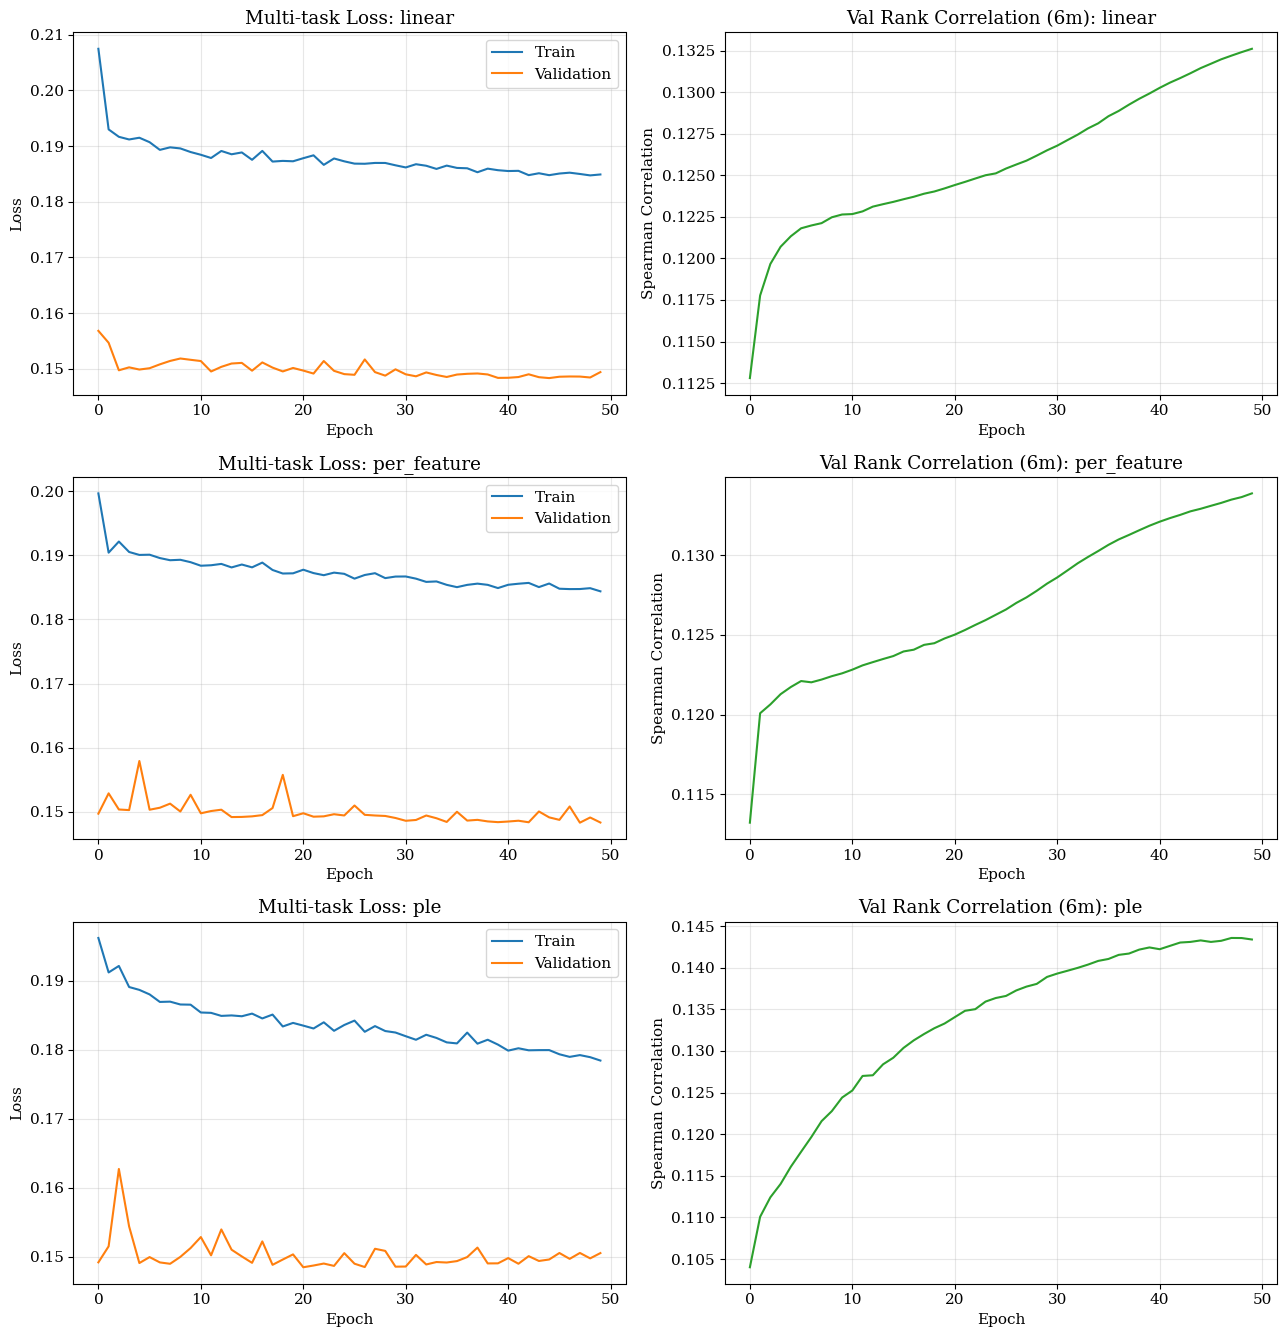

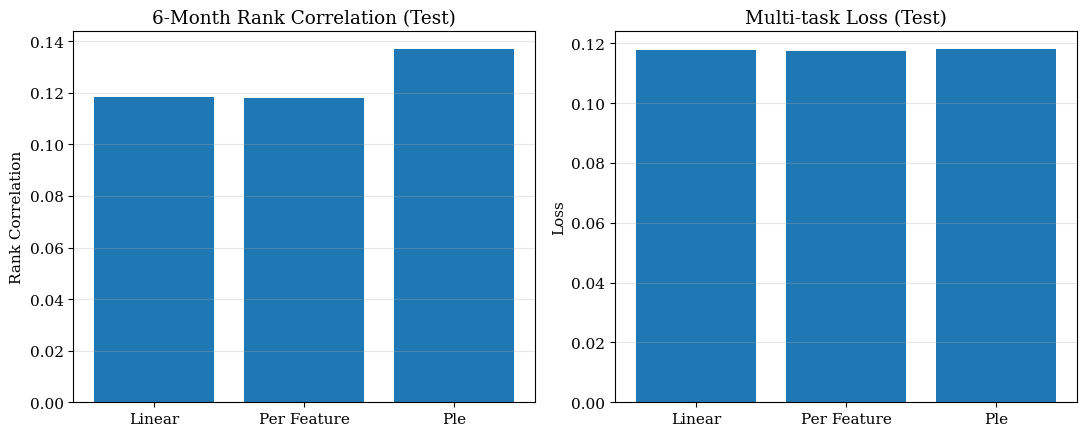

In [20]:
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = 11


def plot_training_curves(all_results):
	n_variants = len(all_results)
	fig, axes = plt.subplots(n_variants, 2, figsize = (13, 4.5 * n_variants))
	if n_variants == 1:
		axes = axes.reshape(1, -1)

	for row, (variant, res) in enumerate(all_results.items()):
		history = res["history"]

		axes[row, 0].plot(history["train_loss"], label = "Train", linewidth = 1.5)
		axes[row, 0].plot(history["val_loss"], label = "Validation", linewidth = 1.5)
		axes[row, 0].set_xlabel("Epoch")
		axes[row, 0].set_ylabel("Loss")
		axes[row, 0].set_title(f"Multi-task Loss: {variant}")
		axes[row, 0].legend()
		axes[row, 0].grid(alpha = 0.3)

		axes[row, 1].plot(history["val_corr_6m"], linewidth = 1.5, color = "tab:green")
		axes[row, 1].set_xlabel("Epoch")
		axes[row, 1].set_ylabel("Spearman Correlation")
		axes[row, 1].set_title(f"Val Rank Correlation (6m): {variant}")
		axes[row, 1].grid(alpha = 0.3)

	plt.tight_layout()
	plt.show()


def plot_variant_comparison(all_results):
	variants = list(all_results.keys())
	corr_6m = [all_results[v]["test_metrics"]["rank_corr"]["target_6m"] for v in variants]
	losses = [all_results[v]["test_metrics"]["loss"] for v in variants]

	fig, axes = plt.subplots(1, 2, figsize = (11, 4.5))
	labels = [v.replace("_", " ").title() for v in variants]

	axes[0].bar(labels, corr_6m)
	axes[0].set_ylabel("Rank Correlation")
	axes[0].set_title("6-Month Rank Correlation (Test)")
	axes[0].grid(axis = "y", alpha = 0.3)

	axes[1].bar(labels, losses)
	axes[1].set_ylabel("Loss")
	axes[1].set_title("Multi-task Loss (Test)")
	axes[1].grid(axis = "y", alpha = 0.3)

	plt.tight_layout()
	plt.show()


plot_training_curves(all_results)
plot_variant_comparison(all_results)

### 11. Portfolio Simulation

In [21]:
@torch.no_grad()
def portfolio_simulation(model, dataset, config, rebalance_freq = 6, transaction_cost_bps = 25):
	"""Long-only portfolio: top quintile by 6-month predicted score, equal weighted."""
	model.eval()
	portfolio_returns = []
	prev_holdings = set()

	for idx in range(0, len(dataset), rebalance_freq):
		batch = dataset[idx]
		k0 = batch["k0"].to(device)
		k1 = batch["k1"].to(device)
		k0_miss = batch["k0_miss"].to(device)
		k1_miss = batch["k1_miss"].to(device)
		cids = batch["country_ids"].to(device)

		output = model(k0, k1, k0_miss, k1_miss, cids)
		scores_6m = output["scores_6m"]

		n_firms = scores_6m.shape[0]
		n_quintile = max(int(0.2 * n_firms), 1)
		_, top_indices = scores_6m.topk(n_quintile)
		top_set = set(top_indices.cpu().numpy().tolist())

		new_holdings = top_set - prev_holdings
		exited = prev_holdings - top_set
		turnover = (len(new_holdings) + len(exited)) / max(len(top_set), 1)
		tc = turnover * transaction_cost_bps / 10000.0

		raw_returns = batch["targets"]["target_6m"]
		valid = batch["valid_masks"]["target_6m"]

		valid_returns = [raw_returns[fi].item() for fi in top_indices.cpu().numpy() if valid[fi]]
		mean_return = sum(valid_returns) / max(len(valid_returns), 1) if valid_returns else 0.0

		portfolio_returns.append(mean_return - tc)
		prev_holdings = top_set

	return np.array(portfolio_returns)


@torch.no_grad()
def portfolio_simulation_long_short(model, dataset, config, rebalance_freq = 6, transaction_cost_bps = 25):
	"""Long-short portfolio: long top quintile, short bottom quintile, score-proportional."""
	model.eval()
	portfolio_returns = []
	prev_long = set()
	prev_short = set()

	for idx in range(0, len(dataset), rebalance_freq):
		batch = dataset[idx]
		k0 = batch["k0"].to(device)
		k1 = batch["k1"].to(device)
		k0_miss = batch["k0_miss"].to(device)
		k1_miss = batch["k1_miss"].to(device)
		cids = batch["country_ids"].to(device)

		output = model(k0, k1, k0_miss, k1_miss, cids)
		scores_6m = output["scores_6m"]

		n_firms = scores_6m.shape[0]
		n_quintile = max(int(0.2 * n_firms), 1)

		_, long_idx = scores_6m.topk(n_quintile)
		_, short_idx = scores_6m.topk(n_quintile, largest = False)

		long_set = set(long_idx.cpu().numpy().tolist())
		short_set = set(short_idx.cpu().numpy().tolist())

		lt = len(long_set - prev_long) + len(prev_long - long_set)
		st = len(short_set - prev_short) + len(prev_short - short_set)
		tc = (lt + st) / max(n_quintile, 1) * transaction_cost_bps / 10000.0

		raw_returns = batch["targets"]["target_6m"]
		valid = batch["valid_masks"]["target_6m"]

		long_w = F.softmax(scores_6m[long_idx], dim = 0)
		long_ret = sum(long_w[i].item() * raw_returns[fi].item()
			for i, fi in enumerate(long_idx.cpu().numpy()) if valid[fi])

		short_w = F.softmax(-scores_6m[short_idx], dim = 0)
		short_ret = sum(short_w[i].item() * raw_returns[fi].item()
			for i, fi in enumerate(short_idx.cpu().numpy()) if valid[fi])

		portfolio_returns.append(long_ret - short_ret - tc)
		prev_long = long_set
		prev_short = short_set

	return np.array(portfolio_returns)


def compute_portfolio_metrics(returns, periods_per_year = 2):
	cum_return = (1 + returns).prod() - 1
	annualised_return = (1 + cum_return) ** (periods_per_year / max(len(returns), 1)) - 1
	annualised_vol = returns.std() * np.sqrt(periods_per_year)
	sharpe = annualised_return / max(annualised_vol, 1e-8)

	cum_wealth = np.cumprod(1 + returns)
	peak = np.maximum.accumulate(cum_wealth)
	drawdown = (peak - cum_wealth) / peak
	max_dd = drawdown.max()

	return {
		"cumulative_return": cum_return,
		"annualised_return": annualised_return,
		"annualised_vol": annualised_vol,
		"sharpe_ratio": sharpe,
		"max_drawdown": max_dd,
		"n_rebalances": len(returns),
	}


best_variant = max(all_results, key = lambda v: all_results[v]["test_metrics"]["rank_corr"]["target_6m"])
print(f"Best variant: {best_variant}")
print()

cfg.encoding_variant = best_variant
best_model = DualPathTransformer(cfg).to(device)
best_model.load_state_dict(torch.load(cfg.results_dir / f"weights_{best_variant}.pt", weights_only = True))

test_ds = load_split(
	cfg.test_path, k0_feature_cols, k1_feature_cols,
	k0_miss_cols, k1_miss_cols, target_cols, COUNTRY_LOOKUP, cfg.max_firms
)

lo_returns = portfolio_simulation(best_model, test_ds, cfg)
ls_returns = portfolio_simulation_long_short(best_model, test_ds, cfg)

print("Long-Only Portfolio:")
for k, v in compute_portfolio_metrics(lo_returns).items():
	print(f"{k}: {v:.4f}")

print()
print("Long-Short Portfolio:")
for k, v in compute_portfolio_metrics(ls_returns).items():
	print(f"{k}: {v:.4f}")

del best_model, test_ds
gc.collect()
torch.cuda.empty_cache()

Best variant: ple

Long-Only Portfolio:
cumulative_return: 1.9247
annualised_return: 0.2394
annualised_vol: 0.2057
sharpe_ratio: 1.1639
max_drawdown: 0.0279
n_rebalances: 10.0000

Long-Short Portfolio:
cumulative_return: 1.8798
annualised_return: 0.2356
annualised_vol: 0.1459
sharpe_ratio: 1.6145
max_drawdown: 0.0615
n_rebalances: 10.0000


### 12. Model Dimension Check

In [22]:
test_cfg = Config()

print("Parameter counts by variant")
for variant in ["linear", "per_feature", "ple", "periodic", "fourier"]:
	test_cfg.encoding_variant = variant
	m = DualPathTransformer(test_cfg).to(device)
	n_test = 100
	k0_t = torch.randn(n_test, len(K0_CHARS), device = device)
	k1_t = torch.randn(n_test, len(K1_CHARS), 6, device = device)
	k0_m = torch.zeros(n_test, len(K0_CHARS), device = device)
	k1_m = torch.zeros(n_test, len(K1_CHARS), device = device)
	cids = torch.zeros(n_test, dtype = torch.long, device = device)
	out = m(k0_t, k1_t, k0_m, k1_m, cids)
	n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
	print(f"{variant:15s} | params:{n_p:>10,} | score shape:{out['scores_6m'].shape} | base shape:{out['base_6m'].shape}")

	del m

gc.collect()
torch.cuda.empty_cache()
print()
print("All encoding variants produce correct output dimensions.")

Parameter counts by variant
linear          | params:   182,600 | score shape:torch.Size([100]) | base shape:torch.Size([100])
per_feature     | params:   182,600 | score shape:torch.Size([100]) | base shape:torch.Size([100])
ple             | params:   318,792 | score shape:torch.Size([100]) | base shape:torch.Size([100])
periodic        | params:   177,096 | score shape:torch.Size([100]) | base shape:torch.Size([100])
fourier         | params:   176,328 | score shape:torch.Size([100]) | base shape:torch.Size([100])

All encoding variants produce correct output dimensions.
